In [319]:
%load_ext autoreload
%autoreload 2

import os
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nb
    
sys.path.insert(1, "../../")

import precision_mapping as pm
import CAP_tools


sys.path.insert(1, "../../network_control")
import surface_mapping as sfm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
exclude_subcortex = True
mask = False
sparsity = 0.1

silent = True

pm.utils.printer.silent = silent

In [314]:
# dtseries_path = "/data/data7/pfmsb_AAAV5170/pilot_data/pfm_test_nico_2025-05-21/MRI_data/fmriprep/ses-zitestpfm/func/sub-PFMTEST_ses-zitestpfm_task-rest_run-01_space-fsLR_den-91k_bold.dtseries.nii"

In [315]:
def load_FC_cortex(FC_path, template_cifti):
    """ """
    sc = scipy.sparse.load_npz(FC_path)
    cortex_index = pm.na.get_cortex_data(np.arange(sc.shape[0]).reshape(1, -1), template_cifti)[0]
    return sc[cortex_index][:, cortex_index]

def load_partition_labels(partition_path, template_cifti):
    """ """
    partition = np.load(partition_path)
    vertex_labels = pm.na.get_partition_cortex(partition, template_cifti)
    vertex_labels[np.isnan(vertex_labels)] = np.nanmax(vertex_labels) + 1
    remapped_vertex_labels = np.unique(vertex_labels, return_inverse=True)[1]
    return remapped_vertex_labels

def load_network_labels(network_path):
    return np.load(network_save_path)[0].astype(int)


def vertex_plot(values, template_cifti, ax=None, pclip=(None, None), **kwargs):
    """ """
    values = CAP_tools.utils.cifti_map(None, values, template_cifti)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    return sfm.surface_plot(values, ax=ax, **kwargs)

In [316]:
def check_multiple_args(args, main_dtype=str):
    """ """
    if any(not isinstance(arg, main_dtype) for arg in args):
        assert all(len(arg) == len(args[0]) for arg in args[1:]), "arg lists not same length"
        return True

    return False

def write_parcel_dlabel(dtseries_path, parcel_partition_path, parcel_dlabel_path, template_cifti):
    """ """
    # list of paths version
    args = [dtseries_path, parcel_partition_path, parcel_dlabel_path]
    if check_multiple_args(args, main_dtype=str):
        np.vectorize(write_parcel_dlabel)(*args, template_cifti=template_cifti)
        return

    vertex_parcel_labels = load_partition_labels(parcel_partition_path, template_cifti)
    
    parcel_values_int = CAP_tools.utils.cifti_map(None, vertex_parcel_labels, template_cifti)
    pm.plot.write_dlabel_precision_map(parcel_values_int, parcel_dlabel_path)


def write_network_dlabel(dtseries_path, network_partition_path, network_dlabel_path, template_cifti):
    """ """
    # list of paths version
    args = [dtseries_path, network_partition_path, network_dlabel_path]
    if check_multiple_args(args, main_dtype=str):
        np.vectorize(write_network_dlabel)(*args, template_cifti=template_cifti)
        return

    # single path version
    vertex_network_labels, vertex_network_strings = np.load(network_partition_path)
    vertex_network_labels = vertex_network_labels.astype(int)
    network_values_int = CAP_tools.utils.cifti_map(None, vertex_network_labels, template_cifti)
    network_name_to_num_map = {z: vertex_network_strings[np.where(vertex_network_labels == z)[0][0]]
                               for z in np.unique(vertex_network_labels)}
    network_dlabel_values = {
        "left": np.array(list(map(network_name_to_num_map.get, network_values_int["left"]))),
        "right": np.array(list(map(network_name_to_num_map.get, network_values_int["right"])))
    }
    pm.plot.write_dlabel_precision_map(network_dlabel_values, network_dlabel_path)


def parcel_plot(parcel_partition_path, network_partition_path, sample_label, save_path, template_cifti, close=True):

    args = [parcel_partition_path, network_partition_path, sample_label, save_path]
    if check_multiple_args(args, main_dtype=str):
        np.vectorize(parcel_plot)(*args, template_cifti=template_cifti, close=close)
        return
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    fig.tight_layout(h_pad=2)
    ax, _ = vertex_plot(vertex_parcel_labels, template_cifti, cmap=plt.cm.Spectral, outline=False, ax=axes[0])
    ax.set_title(f"{sample_label} Assigned Parcels")
    
    ax, _ = vertex_plot(vertex_network_labels, template_cifti, cmap=plt.cm.Spectral, ax=axes[1])
    ax.set_title(f"{sample_label} Assigned Networks")
    
    fig.savefig(parcel_plot_path, bbox_inches='tight')
    
    if close:
        plt.close()
    return

In [317]:
def create_pm_paths(subject_ids, sample_labels, precision_maps_out_dir):
    """ """
    vertex_fc_paths, parcel_partition_paths, network_partition_paths = [], [], []
    parcel_dlabel_paths, network_dlabel_paths, plot_save_paths = [], [], []

    for subject_id, sample_label in zip(subject_ids, sample_labels):
        subject_pm_dir = os.path.join(precision_maps_out_dir, subject_id)
        if not os.path.exists(subject_pm_dir):
            os.mkdir(subject_pm_dir)

        subject_generic_file_name = f"{subject_pm_dir}/{sample_label}_{{file_ending}}"
        
        vertex_fc_paths.append(subject_generic_file_name.format(file_ending="vertex_FC.npz"))
        parcel_partition_paths.append(subject_generic_file_name.format(file_ending="parcel_partition.npy"))
        network_partition_paths.append(subject_generic_file_name.format(file_ending="network_partition.npy"))

        parcel_dlabel_paths.append(subject_generic_file_name.format(file_ending="parcels.dlabel.nii"))
        network_dlabel_paths.append(subject_generic_file_name.format(file_ending="networks.dlabel.nii"))
        plot_save_paths.append(subject_generic_file_name.format(file_ending="_parcellation_plot.png"))

    return vertex_fc_paths, parcel_partition_paths, network_partition_paths, parcel_dlabel_paths, network_dlabel_paths, plot_save_paths

In [318]:
def run_precision_mapping(dtseries_paths, subject_ids, sample_labels, precision_maps_out_dir,
                          overwrite=False, silent=True, device="cpu"):
    """ """

    dtseries_paths = [dtseries_paths] if isinstance(dtseries_paths, str) else dtseries_paths
    subject_ids = [subject_ids] if isinstance(subject_ids, str) else subject_ids
    sample_labels = [sample_labels] if isinstance(sample_labels, str) else sample_labels
    
    path_sets = create_pm_paths(subject_ids, sample_labels, precision_maps_out_dir)
    vertex_fc_paths, parcel_partition_paths, network_partition_paths, _, _, _ = path_sets
    _, _, _, parcel_dlabel_paths, network_dlabel_paths, plot_save_paths = path_sets

    pm.functional_connectivity.generate_correlation_matrix(dtseries_paths, vertex_fc_paths, block_size=1000,
                                                                      overwrite=overwrite, backend="torch", device=device)
    pm.parcellate.parcel_detection(vertex_fc_paths, parcel_partition_paths, n_cores=1, n_reps=1, overwrite=overwrite, silent=silent)
    pm.na.assign_networks_batch(dtseries_paths, parcel_partition_paths, network_partition_paths, overwrite=overwrite)

    
    template_cifti = nb.load(dtseries_paths[0])

    write_parcel_dlabel(dtseries_paths, parcel_partition_paths, parcel_dlabel_paths, template_cifti)
    write_network_dlabel(dtseries_paths, network_partition_paths, network_dlabel_paths, template_cifti)
    parcel_plot(parcel_partition_paths, network_partition_paths, sample_labels, plot_save_paths, template_cifti)
    return path_sets

In [313]:
precision_maps_out_dir = "/System/Volumes/Data/data/data7/pfmsb_AAAV5170/analyses/precision_maps"

In [ ]:
dtseries_path = "/data/data7/pfmsb_AAAV5170/patepfmsb/derivatives/xcp-0.10.0rc3/sub-pfmsb001/ses-00101/func/sub-pfmsb001_ses-00101_task-rest_acq-day1_run-01_space-fsLR_den-91k_desc-denoised_bold.dtseries.nii"

subject_id = "sub-pfmsb001"
sample_label = "sub-pfmsb001_ses-00101_task-rest_acq-day1_run-01"

In [312]:
ps = run_precision_mapping(dtseries_path, subject_id, sample_label, precision_maps_out_dir, overwrite=False, silent=True)

Generating vertex-level FC:   0%|          | 0/1 [00:00<?, ?it/s]

Running infomap parcel detection:   0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Context leak detected, msgtracer returned -1
/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: divide by zero encountered in func (vectorized)
  outputs = ufunc(*inputs)


In [188]:
overwrite = True

pm.functional_connectivity.generate_correlation_matrix(dtseries_path, vertex_fc_path, block_size=1000,
                                                                  overwrite=overwrite, backend="torch", device="cpu")
pm.parcellate.parcel_detection([vertex_fc_path], [parcel_partition_path], n_cores=1, n_reps=1, overwrite=overwrite, silent=False)
# r = pm.na.assign_networks_batch([dtseries_path], [parcel_partition_path], [network_partition_path], overwrite=True)

tensor(0.0084)


SparseCorrelator Block Analysis:   0%|          | 0/4278.0 [00:00<?, ?it/s]

Running infomap parcel detection:   0%|          | 0/1 [00:00<?, ?it/s]

/System/Volumes/Data/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/sub-pfmsb001_ses-00101_task-rest_acq-day1_run-01_vertex_FC.npz
  Infomap v2.8.0 starts at 2025-09-23 16:38:09
  -> Input network: 
  -> No file output!
  -> Configuration: two-level
                    seed = 42
  -> Ordinary network input, using the Map Equation for first order network flows
Calculating global network flow using flow model 'undirected'... 
  -> Using undirected links.
  => Sum node flow: 1, sum link flow: 1
Build internal network with 79971 nodes and 8332312 links...
  -> One-level codelength: 15.0115019

Trial 1/1 starting at 2025-09-23 16:38:15
Two-level compression: 15% 1.3% 0.00149254927% 0.0125551604% 

[(array([    0,     1,     2, ..., 91277, 91278, 91281], shape=(79971,)),
  array([ 20, 513,  10, ...,   1,   4,   1], shape=(79971,)))]

# Plotting

In [142]:
dtseries_path, network_path, parcellation_path

parcel_dlabel_path = "scratch/parcels.dlabel.nii"
network_dlabel_path = "scratch/networks.dlabel.nii"


template_cifti = nb.load(dtseries_path)

vertex_parcel_labels = load_partition_labels(parcellation_path, template_cifti)
parcel_values_int = CAP_tools.utils.cifti_map(None, vertex_parcel_labels, template_cifti)
pm.plot.write_dlabel_precision_map(parcel_values_int, parcel_dlabel_path)


vertex_network_labels, vertex_network_strings = np.load(network_path)
vertex_network_labels = vertex_network_labels.astype(int)
network_values_int = CAP_tools.utils.cifti_map(None, vertex_network_labels, example_cifti)
network_name_to_num_map = {z: vertex_network_strings[np.where(vertex_network_labels == z)[0][0]]
                           for z in np.unique(vertex_network_labels)}
network_dlabel_values = {
    "left": np.array(list(map(network_name_to_num_map.get, network_values_int["left"]))),
    "right": np.array(list(map(network_name_to_num_map.get, network_values_int["right"])))
}
pm.plot.write_dlabel_precision_map(network_dlabel_values, network_dlabel_path)

In [309]:
template_cifti = nb.load(dtseries_path)

write_parcel_dlabel([dtseries_path], [parcel_partition_path], [parcel_dlabel_path], template_cifti)
write_network_dlabel([dtseries_path], [network_partition_path], [network_dlabel_path], template_cifti)

In [231]:
parcel_plot_path = ps[-1][0].replace("_networks.dlabel.nii", "parcellation.png")

In [241]:
ps[0]

(['/System/Volumes/Data/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/sub-pfmsb001_ses-00101_task-rest_acq-day1_run-01_vertex_FC.npz'],
 ['/System/Volumes/Data/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/sub-pfmsb001_ses-00101_task-rest_acq-day1_run-01_parcel_partition.npy'],
 ['/System/Volumes/Data/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/sub-pfmsb001_ses-00101_task-rest_acq-day1_run-01_network_partition.npy'],
 ['/System/Volumes/Data/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/sub-pfmsb001_ses-00101_task-rest_acq-day1_run-01__parcels.dlabel.nii'],
 ['/System/Volumes/Data/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/sub-pfmsb001_ses-00101_task-rest_acq-day1_run-01__networks.dlabel.nii'])

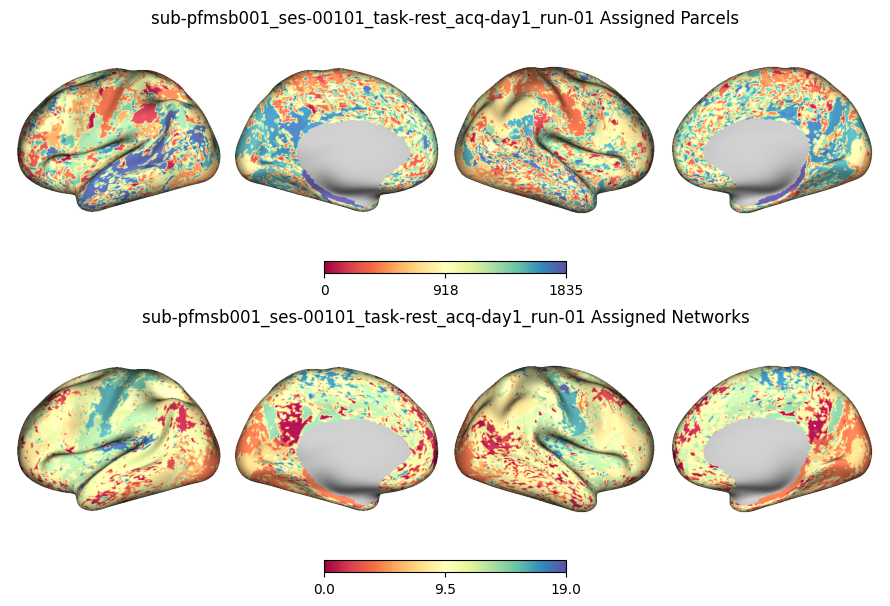

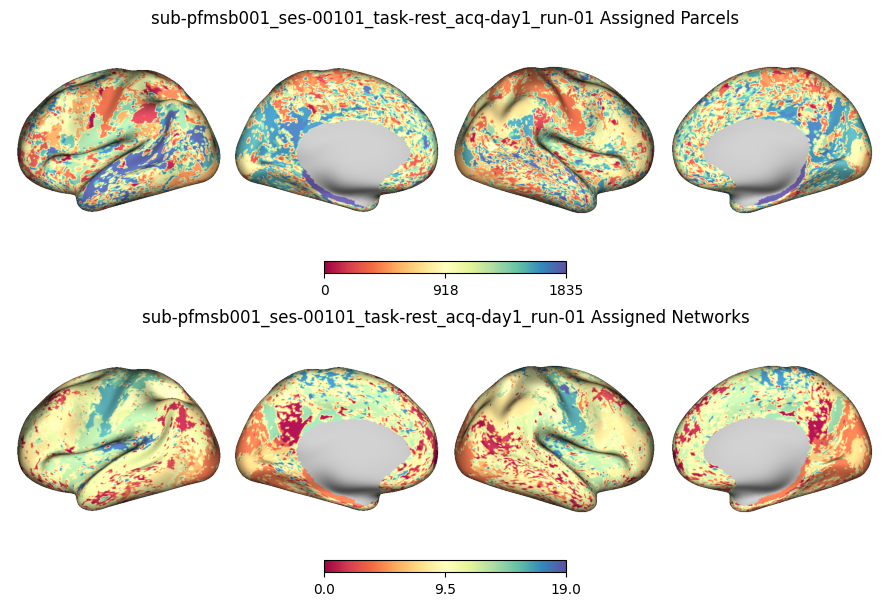

In [302]:
parcel_plot([parcel_partition_path], [network_partition_path], [sample_label], [parcel_plot_path], template_cifti, close=False)